In [3]:
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import numpy as np
import cv2

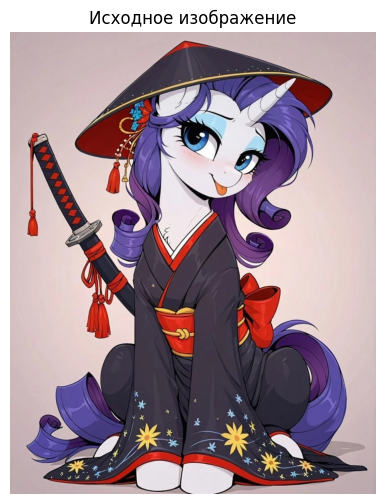

In [4]:


image_path = r"E:\HSE\ФКН\MlOps\jqm2dRb3GDA.jpg"

try:
    image = Image.open(image_path)

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title("Исходное изображение")
    plt.show()
except Exception as e:
    print("Ошибка при загрузке изображения:", e)

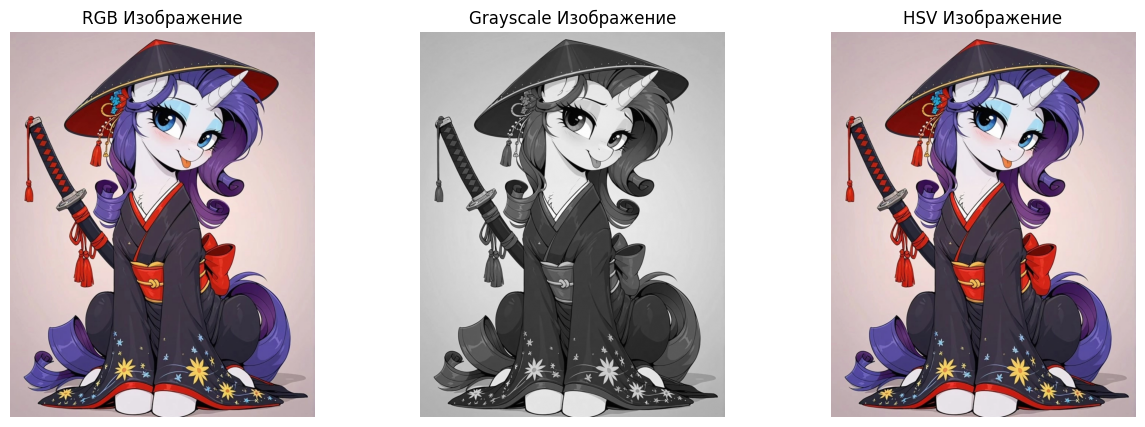

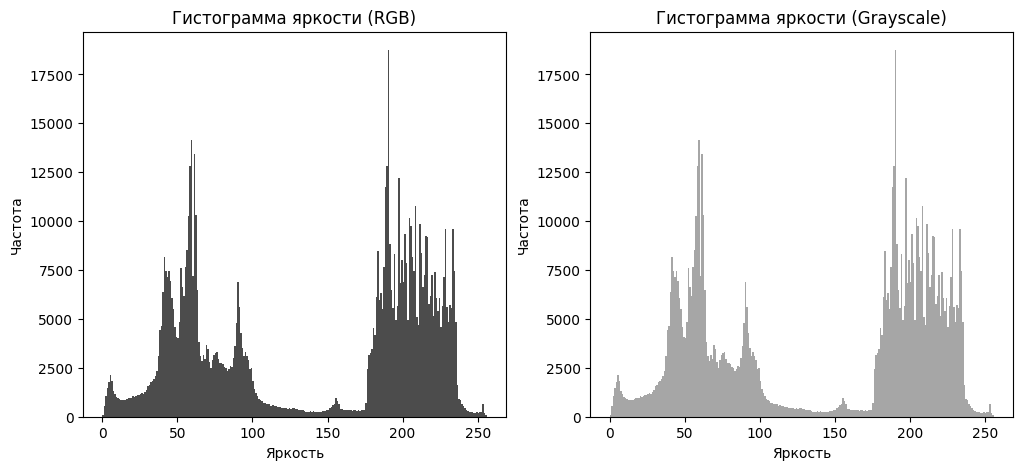

In [5]:
image_path = r"E:\HSE\ФКН\MlOps\jqm2dRb3GDA.jpg"
image = Image.open(image_path)

#конвертация в Grayscale
image_gray = ImageOps.grayscale(image)

#конвертация в HSV 
image_hsv = image.convert("HSV")


fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(image)
axs[0].set_title("RGB Изображение")
axs[0].axis("off")

axs[1].imshow(image_gray, cmap="gray")
axs[1].set_title("Grayscale Изображение")
axs[1].axis("off")

axs[2].imshow(image_hsv)
axs[2].set_title("HSV Изображение")
axs[2].axis("off")

plt.show()


fig, axs = plt.subplots(1, 2, figsize=(12, 5))

#гистограмма яркости цветного изображения
image_array = np.array(image.convert("L"))  
axs[0].hist(image_array.ravel(), bins=256, range=[0, 256], color='black', alpha=0.7)
axs[0].set_title("Гистограмма яркости (RGB)")
axs[0].set_xlabel("Яркость")
axs[0].set_ylabel("Частота")

#гистограмма яркости серого изображения
image_gray_array = np.array(image_gray)
axs[1].hist(image_gray_array.ravel(), bins=256, range=[0, 256], color='gray', alpha=0.7)
axs[1].set_title("Гистограмма яркости (Grayscale)")
axs[1].set_xlabel("Яркость")
axs[1].set_ylabel("Частота")

plt.show()



RGB изображение содержит всю цветовую информацию, оно выглядит естественно.
Grayscale изображение представляет собой черно-белую версию, где яркость каждого пикселя рассчитывается на основе цветовых компонентов.
HSV изображение показывает, как цвета воспринимаются с точки зрения оттенка, насыщенности и яркости, сохраняя детали, но изменяя цветовое представление.

Анализ гистограмм яркости:

Гистограмма яркости для RGB показывает распределение интенсивностей цвета. Видно, что пиксели распределены неравномерно, что может свидетельствовать о наличии теней и ярких участков.
Гистограмма яркости для Grayscale имеет схожую форму, но без цветных каналов, поскольку изображение теперь представлено в одном измерении яркости.

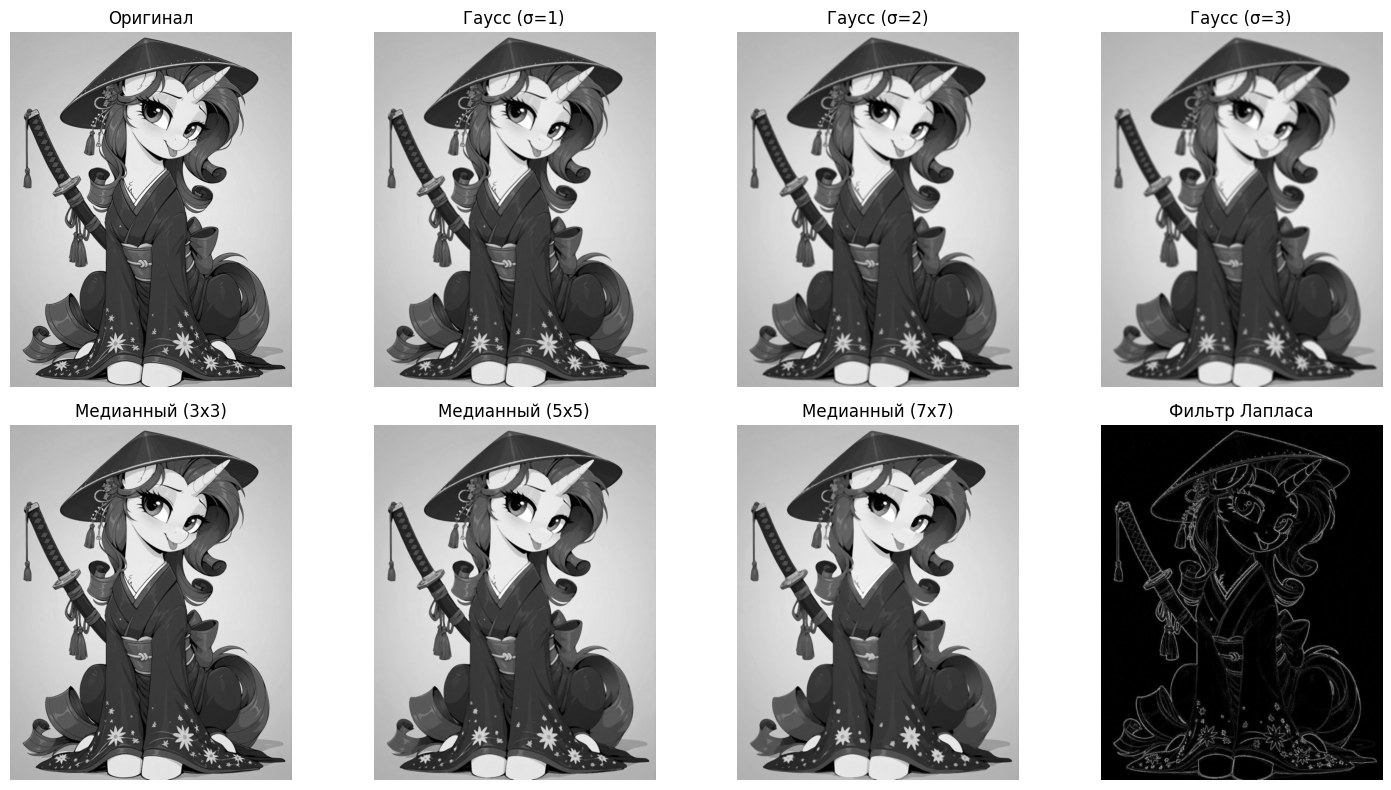

In [6]:

image_path = r"E:\HSE\ФКН\MlOps\jqm2dRb3GDA.jpg"
image_pil = Image.open(image_path).convert("L")  # Перевод в Grayscale
image_gray_np = np.array(image_pil)  # Преобразуем в numpy-массив

#гауссово сглаживание (разные значения сигмы)
gaussian_blur_1 = cv2.GaussianBlur(image_gray_np, (5, 5), 1)
gaussian_blur_2 = cv2.GaussianBlur(image_gray_np, (7, 7), 2)
gaussian_blur_3 = cv2.GaussianBlur(image_gray_np, (9, 9), 3)

#медианный фильтр (разные размеры ядра)
median_blur_1 = cv2.medianBlur(image_gray_np, 3)
median_blur_2 = cv2.medianBlur(image_gray_np, 5)
median_blur_3 = cv2.medianBlur(image_gray_np, 7)

#фильтр Лапласа для повышения резкости
laplacian = cv2.Laplacian(image_gray_np, cv2.CV_64F)
laplacian_abs = np.uint8(np.absolute(laplacian))  # Преобразуем в 8-битное изображение

fig, axs = plt.subplots(2, 4, figsize=(15, 8))

#оригинал
axs[0, 0].imshow(image_gray_np, cmap="gray")
axs[0, 0].set_title("Оригинал")
axs[0, 0].axis("off")

#гауссово сглаживание
axs[0, 1].imshow(gaussian_blur_1, cmap="gray")
axs[0, 1].set_title("Гаусс (σ=1)")
axs[0, 1].axis("off")

axs[0, 2].imshow(gaussian_blur_2, cmap="gray")
axs[0, 2].set_title("Гаусс (σ=2)")
axs[0, 2].axis("off")

axs[0, 3].imshow(gaussian_blur_3, cmap="gray")
axs[0, 3].set_title("Гаусс (σ=3)")
axs[0, 3].axis("off")

#медианный фильтр
axs[1, 0].imshow(median_blur_1, cmap="gray")
axs[1, 0].set_title("Медианный (3x3)")
axs[1, 0].axis("off")

axs[1, 1].imshow(median_blur_2, cmap="gray")
axs[1, 1].set_title("Медианный (5x5)")
axs[1, 1].axis("off")

axs[1, 2].imshow(median_blur_3, cmap="gray")
axs[1, 2].set_title("Медианный (7x7)")
axs[1, 2].axis("off")

#фильтр Лапласа
axs[1, 3].imshow(laplacian_abs, cmap="gray")
axs[1, 3].set_title("Фильтр Лапласа")
axs[1, 3].axis("off")

plt.tight_layout()
plt.show()

Гауссово сглаживание (разные σ):

Уменьшает шум и делает изображение более размытым.
При увеличении σ (1 → 2 → 3) размытие становится сильнее, детали теряются.
Хорошо подходит для подавления случайного шума.

Медианный фильтр (разные размеры ядра):

Удаляет импульсный шум (соляно-перцовый) и сглаживает изображение.
При увеличении размера ядра (3×3 → 5×5 → 7×7) детали сглаживаются сильнее.
В отличие от Гаусса, медианный фильтр сохраняет границы объектов.

Фильтр Лапласа:

Выделяет контуры и усиливает границы объектов.
Позволяет обнаружить резкие переходы яркости.
Чаще используется в комбинации с другими фильтрами.

Гауссово размытие эффективно для удаления шума, но может размыть важные детали.
Медианный фильтр лучше сохраняет границы и подходит для устранения точечных шумов.
Фильтр Лапласа выделяет границы, но не устраняет шум — его лучше использовать вместе с Гауссовым фильтром.

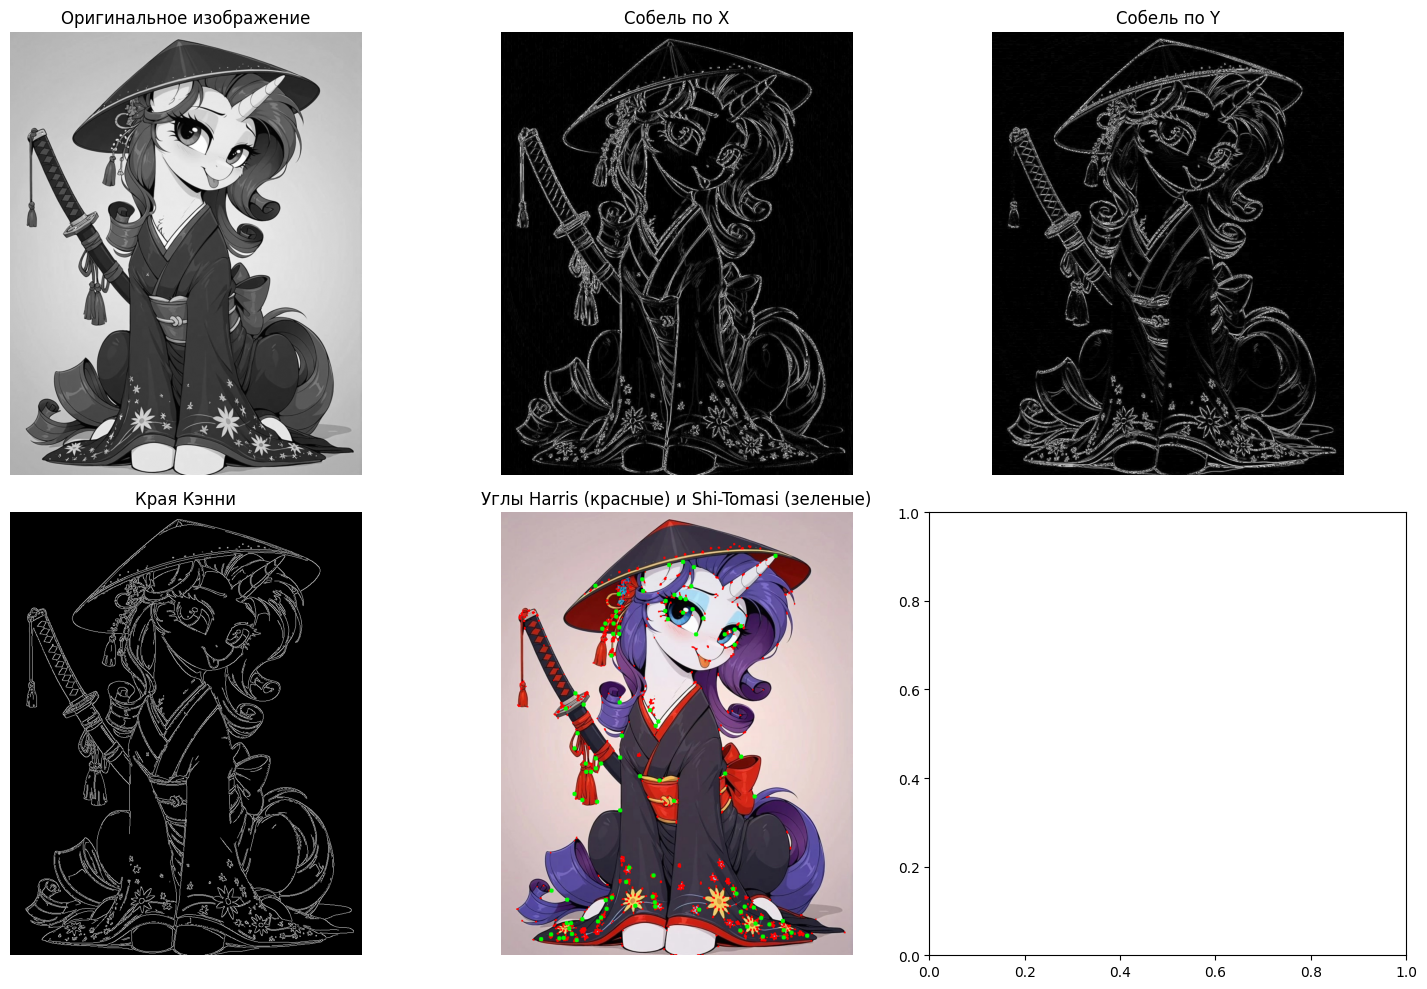

In [7]:
image_gray = Image.open(image_path).convert("L")
image_gray_np = np.array(image_gray)

#оператор Собеля (градиенты по X и Y)
sobel_x = cv2.Sobel(image_gray_np, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(image_gray_np, cv2.CV_64F, 0, 1, ksize=3)

sobel_x_abs = np.uint8(np.absolute(sobel_x))
sobel_y_abs = np.uint8(np.absolute(sobel_y))

#алгоритм Кэнни для обнаружения краев
edges = cv2.Canny(image_gray_np, 100, 200)

#детектор углов Harris
harris_corners = cv2.cornerHarris(np.float32(image_gray_np), blockSize=2, ksize=3, k=0.04)
harris_corners = cv2.dilate(harris_corners, None)  # Утолщаем точки углов

#детектор углов Shi-Tomasi
shi_tomasi_corners = cv2.goodFeaturesToTrack(image_gray_np, maxCorners=100, qualityLevel=0.01, minDistance=10)

#наложение результатов на изображение
image_with_harris = Image.open(image_path).convert("RGB")
image_with_harris_np = np.array(image_with_harris)

#красные точки для Harris
image_with_harris_np[harris_corners > 0.01 * harris_corners.max()] = [255, 0, 0]

#зеленые точки для Shi-Tomasi
if shi_tomasi_corners is not None:
    for corner in np.intp(shi_tomasi_corners):
        x, y = corner.ravel()
        cv2.circle(image_with_harris_np, (x, y), 5, (0, 255, 0), -1)


fig, axs = plt.subplots(2, 3, figsize=(15, 10))

#оригинал
axs[0, 0].imshow(image_gray_np, cmap="gray")
axs[0, 0].set_title("Оригинальное изображение")
axs[0, 0].axis("off")

#градиенты Собеля
axs[0, 1].imshow(sobel_x_abs, cmap="gray")
axs[0, 1].set_title("Собель по X")
axs[0, 1].axis("off")

axs[0, 2].imshow(sobel_y_abs, cmap="gray")
axs[0, 2].set_title("Собель по Y")
axs[0, 2].axis("off")

#края Кэнни
axs[1, 0].imshow(edges, cmap="gray")
axs[1, 0].set_title("Края Кэнни")
axs[1, 0].axis("off")

#углы Harris + Shi-Tomasi
axs[1, 1].imshow(image_with_harris_np)
axs[1, 1].set_title("Углы Harris (красные) и Shi-Tomasi (зеленые)")
axs[1, 1].axis("off")

plt.tight_layout()
plt.show()

Описание методов:

Оператор Собеля (градиенты по X и Y):

Sobel X выделяет вертикальные границы объекта (различия по горизонтали).
Sobel Y выделяет горизонтальные границы (различия по вертикали).
В результате получены изображения с четкими границами, на которых хорошо различимы контуры объекта.

Алгоритм Кэнни для обнаружения краев:

Этот метод комбинирует размытие Гаусса, градиенты Собеля и пороговую фильтрацию для выделения самых значимых границ.
На выходном изображении видны только четко определенные контуры объекта, шумы при этом минимальны.
Этот метод хорошо подходит для поиска объектов и контуров в изображениях.

Детектор углов Harris:

Этот метод позволяет находить точки, где градиент резко меняется в разных направлениях.
Углы выделены красным цветом, они хорошо заметны на изображении.
Детектор Harris лучше работает в местах, где пересекаются линии и есть четкие угловые переходы.

Детектор углов Shi-Tomasi:

Это более точный метод по сравнению с Harris, он отбирает наиболее значимые углы.
Углы Shi-Tomasi выделены зелеными точками и выглядят точнее, чем в случае с Harris.
Метод Shi-Tomasi более устойчив к шуму, поэтому дает меньше ложных углов.


Оператор Собеля помогает анализировать направление градиента (горизонтальное или вертикальное).
Алгоритм Кэнни выделяет четкие контуры и границы, убирая шумы. (он хорошо картинку распознал)
Детектор Harris выделяет углы, но чувствителен к шуму.
Shi-Tomasi является более точным методом определения углов, выделяя самые важные точки. (но на картинке он как будто бы плохо справился с задачей) 

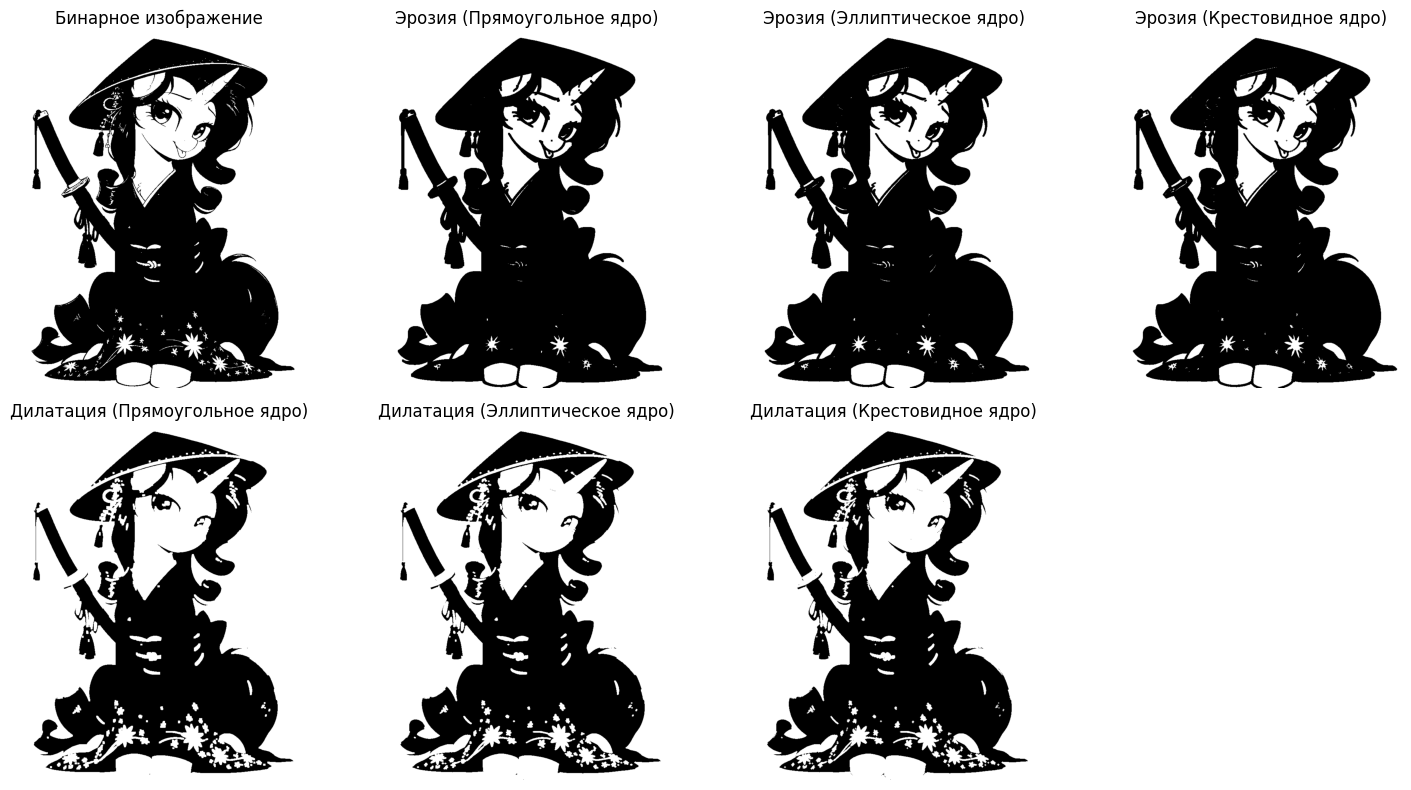

In [8]:
image_gray = Image.open(image_path).convert("L")
image_gray_np = np.array(image_gray)

#бинаризация изображения 
_, binary_image = cv2.threshold(image_gray_np, 127, 255, cv2.THRESH_BINARY)

#создание структурных элементов 
kernel_rect = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
kernel_ellipse = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
kernel_cross = cv2.getStructuringElement(cv2.MORPH_CROSS, (5, 5))

#эрозия (уменьшение белых областей, удаление шума) 
erosion_rect = cv2.erode(binary_image, kernel_rect, iterations=1)
erosion_ellipse = cv2.erode(binary_image, kernel_ellipse, iterations=1)
erosion_cross = cv2.erode(binary_image, kernel_cross, iterations=1)

#дилатация (увеличение белых областей, закрытие разрывов) 
dilation_rect = cv2.dilate(binary_image, kernel_rect, iterations=1)
dilation_ellipse = cv2.dilate(binary_image, kernel_ellipse, iterations=1)
dilation_cross = cv2.dilate(binary_image, kernel_cross, iterations=1)

fig, axs = plt.subplots(2, 4, figsize=(15, 8))  # 2 строки вместо 3

#бинаризация и эрозия 
axs[0, 0].imshow(binary_image, cmap="gray")
axs[0, 0].set_title("Бинарное изображение")
axs[0, 0].axis("off")

axs[0, 1].imshow(erosion_rect, cmap="gray")
axs[0, 1].set_title("Эрозия (Прямоугольное ядро)")
axs[0, 1].axis("off")

axs[0, 2].imshow(erosion_ellipse, cmap="gray")
axs[0, 2].set_title("Эрозия (Эллиптическое ядро)")
axs[0, 2].axis("off")

axs[0, 3].imshow(erosion_cross, cmap="gray")
axs[0, 3].set_title("Эрозия (Крестовидное ядро)")
axs[0, 3].axis("off")

#дилатация 
axs[1, 0].imshow(dilation_rect, cmap="gray")
axs[1, 0].set_title("Дилатация (Прямоугольное ядро)")
axs[1, 0].axis("off")

axs[1, 1].imshow(dilation_ellipse, cmap="gray")
axs[1, 1].set_title("Дилатация (Эллиптическое ядро)")
axs[1, 1].axis("off")

axs[1, 2].imshow(dilation_cross, cmap="gray")
axs[1, 2].set_title("Дилатация (Крестовидное ядро)")
axs[1, 2].axis("off")


fig.delaxes(axs[1, 3])

plt.tight_layout()
plt.show()

Применена пороговая сегментация, преобразующая изображение в чёрно-белый формат.
Пиксели с яркостью выше 127 стали белыми (255), а ниже 127 — чёрными (0).
Это важно для морфологических операций, так как они применяются к бинарным изображениям.

Эрозия уменьшает белые области, удаляя мелкие шумы и детали.
Использовались три разных типа структурных элементов:
Прямоугольное ядро – равномерно уменьшает белые пиксели.
Эллиптическое ядро – более мягкое уменьшение, сглаживает формы.
Крестовидное ядро – сильнее размывает по диагональным направлениям.

Наблюдения:
Прямоугольное и эллиптическое ядро убрали тонкие линии и мелкие детали.
Крестовидное ядро дало менее агрессивную эрозию.

Дилатация увеличивает белые области, помогая восстановить потерянные пиксели.
Использовались те же три ядра:
Прямоугольное ядро – расширяет белые пиксели равномерно.
Эллиптическое ядро – слегка сглаживает расширенные границы.
Крестовидное ядро – даёт менее симметричное расширение.

Наблюдения:
После эрозии некоторые детали пропали, но дилатация восстановила некоторые элементы.
Причем от вида ядер особо ничего не поменялось.